## Note

This notebook has been tested and validated on UCL’s Unified AI platform, a high-performance AI infrastructure for research at UCL, using a namespace configured with 5 CPUs and 64 GB RAM.

The notebook should also run in any standard environment, provided that the required dependencies are installed.

If you need support with AI platforms, with or without GPUs, Carpentries training, or any other computing-related resources, please do not hesitate to contact the ARC Collaborations team at ARC.Collaborations@ucl.ac.uk.

# 1. Formulate / Outline the problem: weather prediction

> The weather prediction dataset (the light version) which can be downloaded from Zenodo. 
It contains daily weather observations from 11 different European cities 
or places through the years 2000 to 2010.

> ### Aim 
> A very common task with weather data is to make a prediction about the weather sometime in the future, 
> say the next day. 
> In this episode, we will try to predict tomorrow’s sunshine hours, a challenging-to-predict feature, 
> using a neural network with the available weather data for one location: BASEL.

# 2. Identify inputs and outputs

In [32]:
# Import Dataset
import time
import pandas as pd

data = pd.read_csv("https://zenodo.org/record/5071376/files/weather_prediction_dataset_light.csv?download=1")

In [33]:
#data.head()
data

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,-15.2,-17.0,-13.4,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,-13.7,-15.0,-12.3,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,-9.2,-12.5,-5.8,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,-5.6,-7.0,-4.2,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,-7.6,-9.4,-5.8,0.95,1.0209,0.39,0.04,8.0,6.4,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649,20091228,12,7,0.82,1.0084,0.28,0.42,0.3,3.2,1.0,...,-15.1,-16.2,-14.0,0.95,1.0011,0.22,1.50,6.2,1.8,10.6
3650,20091229,12,7,0.92,1.0028,0.22,1.68,0.2,4.5,2.4,...,-10.9,-14.4,-7.3,0.89,0.9966,0.24,0.40,10.4,6.2,14.5
3651,20091230,12,8,0.92,0.9979,0.07,1.54,0.0,8.5,7.5,...,-6.6,-7.6,-5.6,0.88,0.9939,0.24,1.00,10.0,8.7,11.3
3652,20091231,12,7,0.93,0.9958,0.17,0.57,0.1,6.6,4.3,...,-7.2,-8.9,-5.4,0.88,0.9933,0.58,0.02,8.5,6.2,10.9


In [34]:
#Brief exploration of the data
data.columns

Index(['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity',
       'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation',
       'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max',
       'DE_BILT_cloud_cover', 'DE_BILT_humidity', 'DE_BILT_pressure',
       'DE_BILT_global_radiation', 'DE_BILT_precipitation', 'DE_BILT_sunshine',
       'DE_BILT_temp_mean', 'DE_BILT_temp_min', 'DE_BILT_temp_max',
       'DRESDEN_cloud_cover', 'DRESDEN_humidity', 'DRESDEN_global_radiation',
       'DRESDEN_precipitation', 'DRESDEN_sunshine', 'DRESDEN_temp_mean',
       'DRESDEN_temp_min', 'DRESDEN_temp_max', 'DUSSELDORF_cloud_cover',
       'DUSSELDORF_humidity', 'DUSSELDORF_pressure',
       'DUSSELDORF_global_radiation', 'DUSSELDORF_precipitation',
       'DUSSELDORF_sunshine', 'DUSSELDORF_temp_mean', 'DUSSELDORF_temp_min',
       'DUSSELDORF_temp_max', 'HEATHROW_cloud_cover', 'HEATHROW_humidity',
       'HEATHROW_pressure', 'HEATHROW_global_radiation',
       'HEATH

In [35]:
data.shape
#This will give both the number of samples (3654) and the number of features (89 + month + date).

(3654, 91)

In [36]:
#For any row i, we will use the values of all fields except MONTH and DATE as the input features X.
#We want to use them to forecast the number of sunshine hours of the next day, 
#hence we use the value of the field BASEL_sunshine in the subsequent row (i+1) 
#as the label that we want to predict (y).

nr_rows = 365*3 # 3 years
# data
X_data = data.loc[:nr_rows] # Select first 3 years
X_data = X_data.drop(columns=['DATE', 'MONTH']) # Drop date and month column

# labels (sunshine hours the next day)
y_data = data.loc[1:(nr_rows + 1)]["BASEL_sunshine"]

In [37]:
X_data.shape, y_data.shape

((1096, 89), (1096,))

# 3. Prepare data

In [38]:
from sklearn.model_selection import train_test_split
#As with classical machine learning techniques, it is required in deep learning 
#to split off a hold-out test set which remains untouched during model training and tuning. 
#First we create the training set and leave the remainder of 30 % of the data to the two hold-out sets.
X_train, X_holdout, y_train, y_holdout = train_test_split(X_data, 
                                                          y_data, 
                                                          test_size=0.3, 
                                                          random_state=0)


# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# random_state int, RandomState instance or None, default=None
# Controls the shuffling applied to the data before applying the split.

In [39]:
X_train.shape, y_train.shape, X_holdout.shape, y_holdout.shape

((767, 89), (767,), (329, 89), (329,))

In [40]:
# Now we split the 30 % of the data in two equal sized parts.
X_val, X_test, y_val, y_test = train_test_split(X_holdout, 
                                                y_holdout, 
                                                test_size=0.5, 
                                                random_state=0)

In [41]:
X_val.shape, X_test.shape, y_val.shape, y_test.shape

((164, 89), (165, 89), (164,), (165,))

#### [Intermezzo: How do neural networks learn?]
* Gradient descent
* Batch gradient descent
* Challenge

# 4. Create a model building architecture from scratch


>We compose a network of two hidden layers to start off with something. We go by a scheme with 100 neurons in the first hidden layer and 50 neurons in the second layer. As activation function we settle on the relu function as a it is very robust and widely used. To make our live easier later, we wrap the definition of the network in a function called create_nn().



In [42]:
from tensorflow import keras
keras.utils.set_random_seed(2)

def create_nn(input_shape):
    # Input layer
    inputs = keras.Input(shape=input_shape, name='input')

    # Dense layers
    layers_dense = keras.layers.Dense(100, 'relu')(inputs)
    layers_dense = keras.layers.Dense(50, 'relu')(layers_dense)

    # Output layer
    outputs = keras.layers.Dense(1)(layers_dense)

    return keras.Model(inputs=inputs, outputs=outputs, name="weather_prediction_model")



In [43]:
X_data.shape[1]

89

In [44]:
model = create_nn(input_shape=(X_data.shape[1],))

In [45]:
model.summary()

Model: "weather_prediction_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 89)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │         9,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,101 (55.08 KB)

 Trainable params: 14,101 (55.08 KB)

 Non-trainable params: 0 (0.00 B)

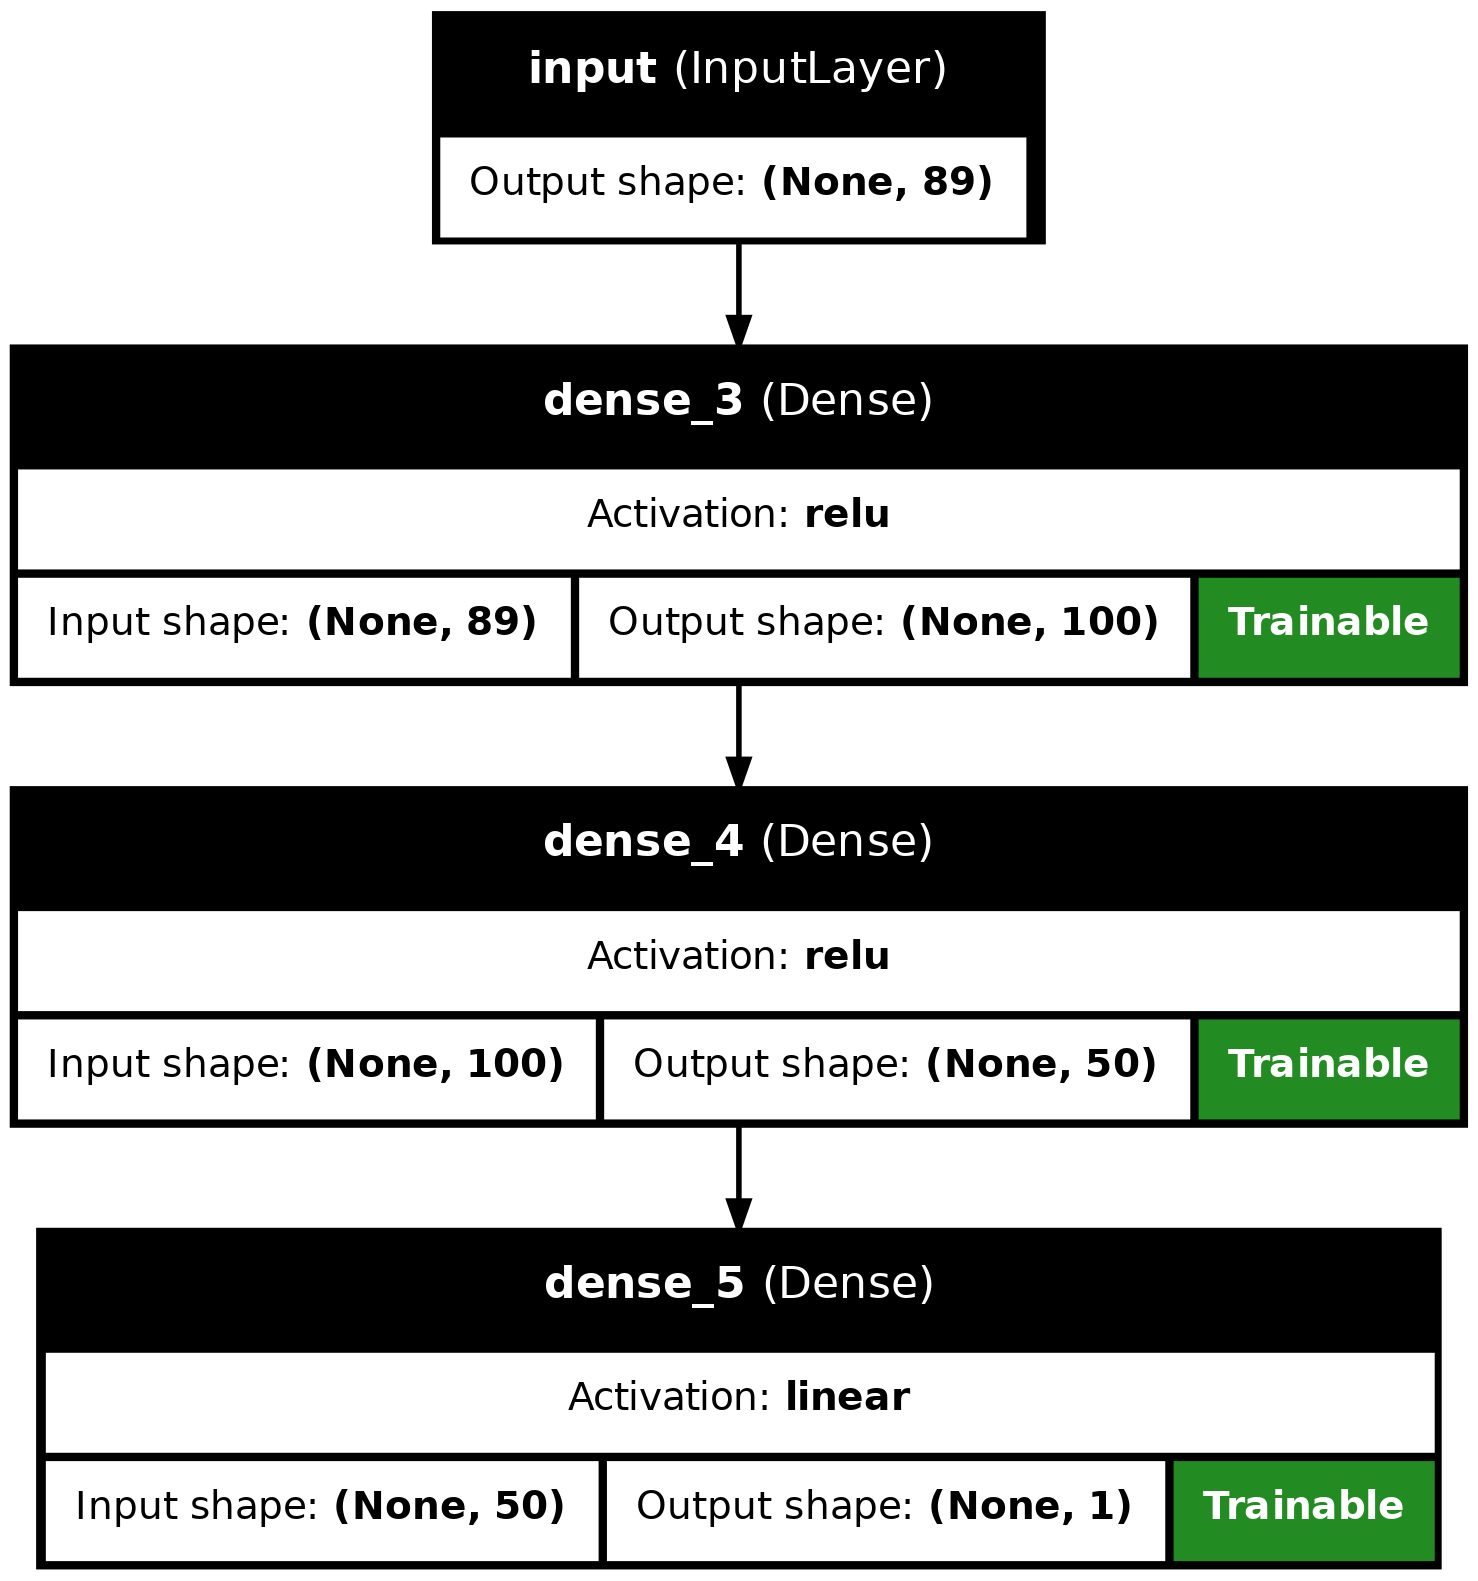

In [46]:
keras.utils.plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
    show_trainable=True
)

# 5. Choose a loss function and optimizer
> Loss function
The loss is what the neural network will be optimized on during training, so choosing a suitable loss function is crucial for training neural networks. In the given case we want to stimulate that the predicted values are as close as possible to the true values. This is commonly done by using the mean squared error (mse) or the mean absolute error (mae), both of which should work OK in this case. Often, mse is preferred over mae because it “punishes” large prediction errors more severely. In Keras this is implemented in the keras.losses.MeanSquaredError class (see Keras documentation: https://keras.io/api/losses/). This can be provided into the model.compile method with the loss parameter and setting it to mse, e.g.


> Optimizer
Somewhat coupled to the loss function is the optimizer that we want to use. The optimizer here refers to the algorithm with which the model learns to optimize on the provided loss function. A basic example for such an optimizer would be stochastic gradient descent. For now, we can largely skip this step and pick one of the most common optimizers that works well for most tasks: the Adam optimizer. Similar to activation functions, the choice of optimizer depends on the problem you are trying to solve, your model architecture and your data. Adam is a good starting point though, which is why we chose it.

> Metrics
In our first example (episode 2) we plotted the progression of the loss during training. That is indeed a good first indicator if things are working alright, i.e. if the loss is indeed decreasing as it should with the number of epochs. However, when models become more complicated then also the loss functions often become less intuitive. That is why it is good practice to monitor the training process with additional, more intuitive metrics. They are not used to optimize the model, but are simply recorded during training. With Keras, such additional metrics can be added via metrics=[...] parameter and can contain one or multiple metrics of interest. Here we could for instance chose mae (mean absolute error), or the the root mean squared error (RMSE) which unlike the mse has the same units as the predicted values. For the sake of units, we choose the latter.



In [15]:
model.compile(loss='mse')

In [16]:
model.compile(optimizer='adam',
              loss='mse')

In [17]:
model.compile(optimizer='adam',
              loss='mse',
              metrics=[keras.metrics.RootMeanSquaredError()])

In [18]:
def compile_model(model):
    model.compile(optimizer='adam',
                  loss='mse',
                  metrics=[keras.metrics.RootMeanSquaredError()])
compile_model(model)

# 6. Train the model

> batch_size parameter that defines – as discussed above – how many samples from the training data will be used to estimate the error gradient before the model weights are updated.  
> Larger batches will produce better, more accurate gradient estimates but also less frequent updates of the weights. Here we are going to use a batch size of 32 which is a common starting point.


In [19]:
# Start the timer
start_time = time.time()

history = model.fit(X_train, y_train,
                    batch_size=32,
                    epochs=200,
                    verbose=0)
#  Verbosity mode. 0 = silent, 1 = progress bar, 2 = one line per epoch.
# https://keras.io/api/models/model_training_apis/


# Calculate and display the elapsed time
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTraining completed in {elapsed_time:.2f} seconds or {elapsed_time/60:.2f} minutes")


Training completed in 16.77 seconds or 0.28 minutes


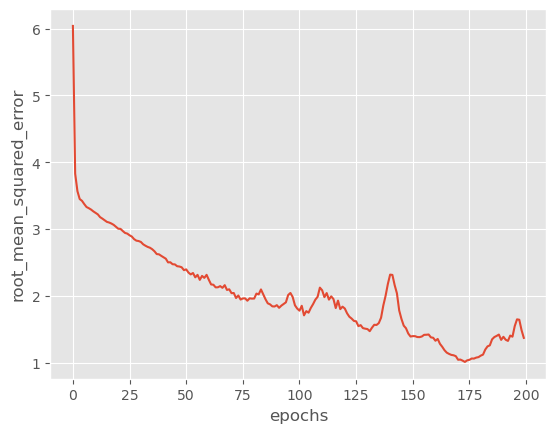

In [20]:
# We can plot the training process using the history object returned from the model training. 
# We will create a function for it, because we will make use of this more often in this lesson!

import seaborn as sns
import matplotlib.pyplot as plt

def plot_history(history, metrics):
    """
    Plot the training history

    Args:
        history (keras History object that is returned by model.fit())
        metrics (str, list): Metric or a list of metrics to plot
    """
    plt.style.use('ggplot')  # optional, that's only to define a visual style
    history_df = pd.DataFrame.from_dict(history.history)
    sns.lineplot(data=history_df[metrics])
    plt.xlabel("epochs")

plot_history(history, 'root_mean_squared_error')


> This looks very promising! Our metric “root_mean_squared_error” (RMSE) is dropping nicely and while it maybe keeps fluctuating a bit it does end up at fairly low values. But this metric is just the root mean squared error, so we might want to look a bit more in detail how well our just trained model does in predicting the sunshine hours.


# 7. Perform a Prediction/Classification
> Now that we have our model trained, we can make a prediction with the model before measuring the performance of our neural network.


In [22]:
y_train_predicted = model.predict(X_train)
y_test_predicted = model.predict(X_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


# 8. Measure performance
> There is not a single way to evaluate how a model performs. But there are at least two very common approaches. For a classification task that is to compute a confusion matrix for the test set which shows how often particular classes were predicted correctly or incorrectly.

> For the present regression task, it makes more sense to compare true and predicted values in a scatter plot.

> So, let’s look at how the predicted sunshine hour have developed with reference to their ground truth values.

In [26]:
# We define a function that we will reuse in this lesson
def plot_predictions(y_pred, y_true, title):
    plt.style.use('ggplot')  # optional, that's only to define a visual style
    plt.scatter(y_pred, y_true, s=10, alpha=0.5)
    plt.axline((0,0),slope = 1, color = "black") # plot diagonal reference line
    plt.xlabel("predicted sunshine hours")
    plt.ylabel("true sunshine hours")
    plt.title(title)


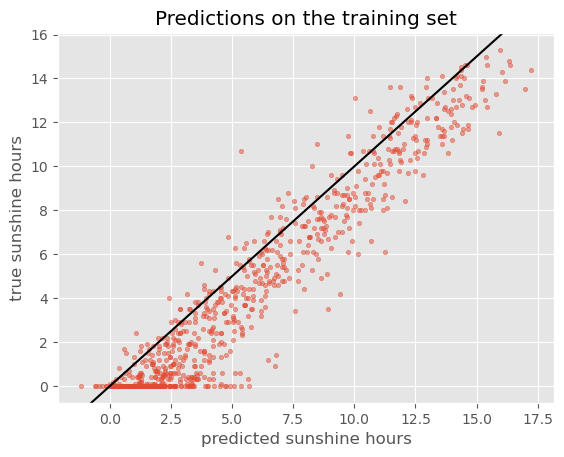

In [27]:
plot_predictions(y_train_predicted, y_train, title='Predictions on the training set')

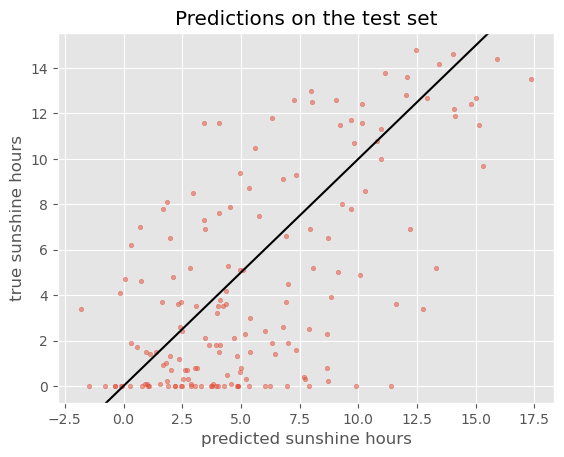

In [28]:
plot_predictions(y_test_predicted, 
                 y_test, 
                 title='Predictions on the test set')

# 8.1 overfitting

> The accuracy on the training set seems fairly good. In fact, considering that the task of predicting the daily sunshine hours is really not easy it might even be surprising how well the model predicts that (at least on the training set). Maybe a little too good? We also see the noticeable difference between train and test set when calculating the exact value of the RMSE:

> For those experienced with (classical) machine learning this might look familiar. The plots above expose the signs of overfitting which means that the model has to some extent memorized aspects of the training data. As a result, it makes much more accurate predictions on the training data than on unseen test data.

> Overfitting also happens in classical machine learning, but there it is usually interpreted as the model having more parameters than the training data would justify (say, a decision tree with too many branches for the number of training instances). As a consequence one would reduce the number of parameters to avoid overfitting. In deep learning the situation is slightly different. It can - as for classical machine learning - also be a sign of having a too big model, meaning a model with too many parameters (layers and/or nodes). However, in deep learning higher number of model parameters are often still considered acceptable and models often perform best (in terms of prediction accuracy) when they are at the verge of overfitting. So, in a way, training deep learning models is always a bit like playing with fire…




In [29]:
train_metrics = model.evaluate(X_train, y_train, return_dict=True)
test_metrics = model.evaluate(X_test, y_test, return_dict=True)
print('Train RMSE: {:.2f}, Test RMSE: {:.2f}'.format(train_metrics['root_mean_squared_error'], test_metrics['root_mean_squared_error']))

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.3541 - root_mean_squared_error: 1.8314 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.9281 - root_mean_squared_error: 3.8637 
Train RMSE: 1.83, Test RMSE: 3.86


# Set expectations: How difficult is the defined problem?
> Before we dive deeper into handling overfitting and (trying to) improving the model performance, let us ask the question: How well must a model perform before we consider it a good model?

> Now that we defined a problem (predict tomorrow’s sunshine hours), it makes sense to develop an intuition for how difficult the posed problem is. Frequently, models will be evaluated against a so called baseline. A baseline can be the current standard in the field or if such a thing does not exist it could also be an intuitive first guess or toy model. The latter is exactly what we would use for our case.

> Maybe the simplest sunshine hour prediction we can easily do is: Tomorrow we will have the same number of sunshine hours as today. (sounds very naive, but for many observables such as temperature this is already a fairly good predictor)

> We can take the BASEL_sunshine column of our data, because this contains the sunshine hours from one day before what we have as a label.

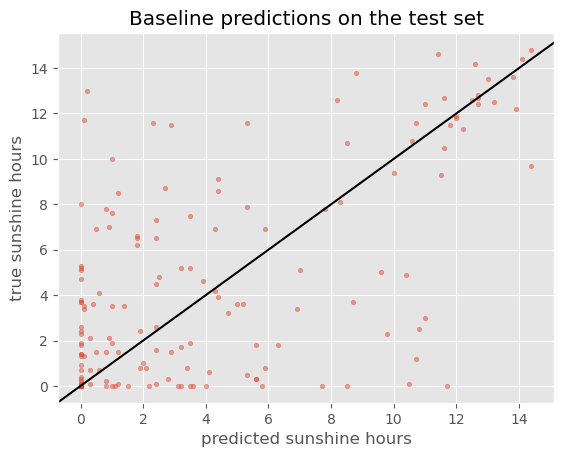

In [30]:
y_baseline_prediction = X_test['BASEL_sunshine']
plot_predictions(y_baseline_prediction, y_test, title='Baseline predictions on the test set')

In [31]:
from sklearn.metrics import root_mean_squared_error
rmse_baseline = root_mean_squared_error(y_test, y_baseline_prediction)

# from sklearn.metrics import mean_squared_error
# rmse_baseline = mean_squared_error(y_test, y_baseline_prediction, squared=False)
print('Baseline:', rmse_baseline)
print('Neural network: ', test_metrics['root_mean_squared_error'])


Baseline: 3.877323350410224
Neural network:  3.8636889457702637


> Judging from the numbers alone, our neural network prediction would be performing worse than the baseline.



# 9. Refine the model

In [ ]:
model = create_nn(input_shape=(X_data.shape[1],))
compile_model(model)

In [ ]:
# Start the timer
start_time = time.time()


history = model.fit(X_train, y_train,
                    batch_size=32,
                    epochs=200,
                    validation_data=(X_val, y_val),
                    verbose=0)

# Calculate and display the elapsed time
end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTraining completed in {elapsed_time:.2f} seconds or {elapsed_time/60:.2f} minutes")

In [ ]:
plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])

In [ ]:
def create_nn(input_shape, nodes1=100, nodes2=50):
   # Input layer
   inputs = keras.layers.Input(shape=input_shape, name='input')
   # Dense layers
   layers_dense = keras.layers.Dense(nodes1, 'relu')(inputs)
   layers_dense = keras.layers.Dense(nodes2, 'relu')(layers_dense)
   # Output layer
   outputs = keras.layers.Dense(1)(layers_dense)
   return keras.Model(inputs=inputs, outputs=outputs, name="model_small")
    

In [ ]:
model = create_nn(input_shape=(X_data.shape[1],), nodes1=10, nodes2=5)
model.summary()

In [ ]:
compile_model(model)

In [ ]:
# Start the timer
start_time = time.time()

history = model.fit(X_train, y_train,
                   batch_size = 32,
                   epochs = 200,
                   validation_data=(X_val, y_val),
                   verbose=0)

# Calculate and display the elapsed time
end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTraining completed in {elapsed_time:.2f} seconds or {elapsed_time/60:.2f} minutes")

In [ ]:
plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])

In [ ]:
model = create_nn(input_shape=(X_data.shape[1],))
compile_model(model)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

earlystopper = EarlyStopping(
    monitor='val_loss',
    patience=10
    )


In [ ]:
# Start the timer
start_time = time.time()


history = model.fit(X_train, y_train,
                    batch_size = 32,
                    epochs = 200,
                    validation_data=(X_val, y_val),
                    callbacks=[earlystopper],
                    verbose=0)

# Calculate and display the elapsed time
end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTraining completed in {elapsed_time:.2f} seconds or {elapsed_time/60:.2f} minutes")

In [ ]:
plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])

In [ ]:
def create_nn(input_shape):
    # Input layer
    inputs = keras.layers.Input(shape=input_shape, name='input')

    # Dense layers
    layers_dense = keras.layers.BatchNormalization()(inputs) # This is new!
    layers_dense = keras.layers.Dense(100, 'relu')(layers_dense)
    layers_dense = keras.layers.Dense(50, 'relu')(layers_dense)

    # Output layer
    outputs = keras.layers.Dense(1)(layers_dense)

    # Defining the model and compiling it
    return keras.Model(inputs=inputs, outputs=outputs, name="model_batchnorm")

model = create_nn(input_shape=(X_data.shape[1],))
compile_model(model)
model.summary()

In [ ]:
# Start the timer
start_time = time.time()

history = model.fit(X_train, y_train,
                    batch_size = 32,
                    epochs = 1000,
                    validation_data=(X_val, y_val),
                    callbacks=[earlystopper],
                    verbose=0)

# Calculate and display the elapsed time
end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTraining completed in {elapsed_time:.2f} seconds or {elapsed_time/60:.2f} minutes")


In [ ]:
plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])

In [ ]:
y_test_predicted = model.predict(X_test)
plot_predictions(y_test_predicted, y_test, title='Predictions on the test set')

In [ ]:
## Exercise: Simplify the model and add data
cols = [c for c in X_data.columns if c[:5] == 'BASEL']
X_data = X_data[cols]



In [ ]:
nr_rows = 365*9
# data
X_data = data.loc[:nr_rows].drop(columns=['DATE', 'MONTH'])

# labels (sunshine hours the next day)
y_data = data.loc[1:(nr_rows + 1)]["BASEL_sunshine"]

In [ ]:
# only use columns with 'BASEL'
cols = [c for c in X_data.columns if c[:5] == 'BASEL']
X_data = X_data[cols]

In [ ]:
X_train, X_holdout, y_train, y_holdout = train_test_split(X_data, y_data, test_size=0.3, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_holdout, y_holdout, test_size=0.5, random_state=0)

In [ ]:
# create the network and view its summary
model = create_nn(input_shape=(X_data.shape[1],))
compile_model(model)
model.summary()

In [ ]:
# Start the timer
start_time = time.time()

history = model.fit(X_train, y_train,
                   batch_size = 32,
                   epochs = 1000,
                   validation_data=(X_val, y_val),
                   callbacks=[earlystopper],
                   verbose = 0)

# Calculate and display the elapsed time
end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTraining completed in {elapsed_time:.2f} seconds or {elapsed_time/60:.2f} minutes")


In [ ]:
plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])

In [ ]:
y_test_predicted = model.predict(X_test)
plot_predictions(y_test_predicted, y_test, title='Predictions on the test set')

In [ ]:
test_metrics = model.evaluate(X_test, y_test, return_dict=True)
print(f'Test RMSE: {test_metrics["root_mean_squared_error"]}')

In [ ]:
# We cannot take all rows, because we need to be able to take the sunshine hours of the next day
nr_rows = len(data) - 2

# data
X_data = data.loc[:nr_rows].drop(columns=['DATE', 'MONTH'])

# labels (sunshine hours the next day)
y_data = data.loc[1:(nr_rows + 1)]["BASEL_sunshine"]

# TensorBoard

In [ ]:
from tensorflow.keras.callbacks import TensorBoard
import datetime
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S") # You can adjust this to add a more meaningful model name
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)


In [ ]:
# Start the timer
start_time = time.time()

history = model.fit(X_train, y_train,
                   batch_size = 32,
                   epochs = 200,
                   validation_data=(X_val, y_val),
                   callbacks=[tensorboard_callback],
                   verbose = 0)

# Calculate and display the elapsed time
end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTraining completed in {elapsed_time:.2f} seconds or {elapsed_time/60:.2f} minutes")

In [ ]:
import os
os.environ["PATH"] += ":/home/jovyan/.local/bin"

In [ ]:
!pwd

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir /logs/fit/20260521-112324 #--load_fast=false


In [ ]:
# !kill 235122